<a href="https://colab.research.google.com/github/Reva694/rawuh-model/blob/main/REVA_SEBRINA_SALSABILA_5231911013_IM_ALPRO_PRAKTIK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 pip install pandas

In [ ]:
import pandas as pd

class DiabetesAnalysis:
    def __init__(self, file_path):
        """Inisialisasi dengan memuat data dari file CSV."""
        self.data = pd.read_csv(file_path)

    def get_summary(self):
        """Mengembalikan ringkasan statistik dari dataset."""
        return self.data.describe()

    def get_outcome_distribution(self):
        """Mengembalikan distribusi outcome (0 dan 1)."""
        return self.data['Outcome'].value_counts(normalize=True)

    def calculate_bmi(self):
        """Menghitung BMI dan menambahkannya ke DataFrame."""
        self.data['BMI'] = self.data['BeratBadan'] / (self.data['Tinggi Badan'] / 100) ** 2
        return self.data[['NamaPasien', 'BMI']]

    def filter_by_glucose(self, threshold):
        """Mengembalikan pasien dengan kadar glukosa di atas threshold tertentu."""
        return self.data[self.data['Glukosa'] > threshold]

    def save_cleaned_data(self, output_file):
        """Menyimpan data yang telah dibersihkan ke file CSV baru."""
        self.data.to_csv(output_file, index=False)

# Contoh penggunaan
if __name__ == "__main__":
    # Ganti 'MultipleFiles/sintetis_diabetes.csv' dengan path file saya
    # Pastikan file 'sintetis_diabetes.csv' ada di direktori yang sama
    # dengan script ini, atau berikan path lengkap ke file tersebut.
    file_path = 'sintetis_diabetes.csv'  # atau '/path/ke/file/sintetis_diabetes.csv'
    analysis = DiabetesAnalysis(file_path)

    # Menampilkan ringkasan statistik
    print("Ringkasan Statistik:")
    print(analysis.get_summary())

    # Menampilkan distribusi outcome
    print("\nDistribusi Outcome:")
    print(analysis.get_outcome_distribution())

    # Menghitung dan menampilkan BMI
    print("\nBMI Pasien:")
    print(analysis.calculate_bmi())

    # Mengfilter pasien dengan kadar glukosa di atas 100
    print("\nPasien dengan kadar glukosa di atas 100:")
    high_glucose_patients = analysis.filter_by_glucose(100)
    print(high_glucose_patients)

    # Menyimpan data yang telah dibersihkan
    analysis.save_cleaned_data('cleaned_diabetes_data.csv')
    print("\nData yang telah dibersihkan disimpan ke 'cleaned_diabetes_data.csv'.")

Ringkasan Statistik:
       BeratBadan  Tinggi Badan         BMI     Glukosa  Tekanan Darah  \
count  100.000000    100.000000  100.000000   98.000000     100.000000   
mean    63.963000    170.223000   22.318000  100.990816     121.607000   
std      9.080934      9.535324    4.149781   21.792740      13.265763   
min     38.800000    150.800000   11.600000   35.200000      88.100000   
25%     59.000000    161.950000   19.875000   86.825000     111.450000   
50%     63.700000    170.850000   22.750000  101.500000     120.750000   
75%     69.100000    175.375000   24.975000  113.675000     130.250000   
max     83.500000    197.200000   31.400000  177.100000     152.800000   

          Outcome  
count  100.000000  
mean     0.250000  
std      0.435194  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      0.250000  
max      1.000000  

Distribusi Outcome:
Outcome
0    0.75
1    0.25
Name: proportion, dtype: float64

BMI Pasien:
    NamaPasien        BMI
0     Pasie

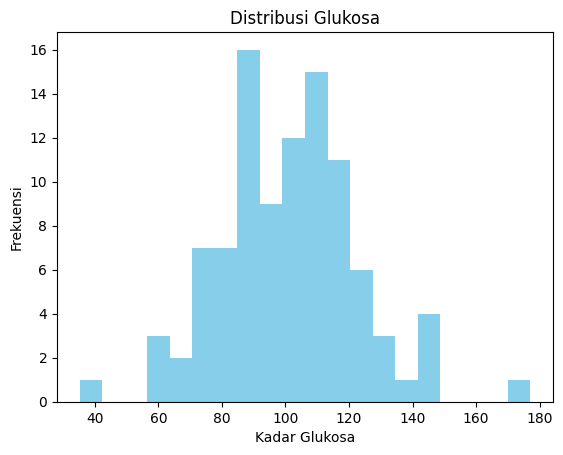

In [ ]:
import matplotlib.pyplot as plt

# Distribusi kolom Glukosa
plt.hist(data['Glukosa'], bins=20, color='skyblue')
plt.title('Distribusi Glukosa')
plt.xlabel('Kadar Glukosa')
plt.ylabel('Frekuensi')
plt.show()


In [ ]:
# Library
import sqlite3

#koneksi
conn = sqlite3.connect("rekam_medis.db")

In [ ]:
#membuat cursor
cursor = conn.cursor()

In [ ]:
#Tabel data pasien
cursor.execute("""
CREATE TABLE IF NOT EXISTS pasien (
   id INTEGER PRIMARY KEY AUTOINCREMENT,
   nama TEXT NOT NULL,
   umur INTEGER NOT NULL,
   jenis_kelamin TEXT NOT NULL,
   diagnosis TEXT NOT NULL,
   tanggal_diagnosis TEXT DEFAULT (DATE('now'))
)
""")
print("Tabel berhasil dibuat")

Tabel berhasil dibuat


In [ ]:
# Fungsi menambahkan data pasien
def tambah_pasien(nama, umur, jenis_kelamin, diagnosis):
  cursor.execute("""
  INSERT INTO pasien (nama, umur, jenis_kelamin, diagnosis)
  VALUES (?, ?, ?, ?)
  """, (nama, umur, jenis_kelamin, diagnosis))
  conn.commit
  print("Data pasien berhasil ditambahkan")

# Fungsi membaca semua data pasien
  def baca_pasien():
    cursor.execute("SELECT * FROM pasien")
    data = cursor.fetchall()
    print("Data pasien:")
    for row in data:
      print(row)

# Fungsi mengubah data pasien
def ubah_data_pasien(id_pasien, nama, umur, jenis_kelamin, diagnosis_baru):
  cursor.execute("""
  SET nama = ?, umur = ?, jenis_kelamin = ?, diagnosis = ?
  WHERE id = ?
  """, (nama, umur, jenis_kelamin, diagnosis, id_pasien))
  conn.commit()
  print(f'Data pasien dengan ID {id_pasien} berhasil diubah')

# Fungsi menghapus data pasien
def hapus_pasien(id_pasien):
  cursor.execute("DELETE FROM pasien WHERE id = ?", (id_pasien,))
  conn.commit()
  print(f'Data pasien dengan ID {id_pasien} berhasil dihapus')

In [ ]:
#tambah data pasien
tambah_pasien("Nabila", 18, "perempuan", "Diare")

Data pasien berhasil ditambahkan
